In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import integrate, optimize
from scipy.stats import norm, qmc
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler


# --- 1. Global Academic Plot Settings ---
plt.rcParams.update({
    'font.family': 'serif',          # Serif font matches LaTeX documents
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.linewidth': 1.2,           # Thicker axes edges
    'xtick.direction': 'in',         # Inward pointing ticks
    'ytick.direction': 'in',
    'xtick.top': True,               # Ticks on top and right axes
    'ytick.right': True,
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False          # Remove box around legend
})

## Practica 3: Emulator for luminosity distance

#### 2 Train a Neural Network for the luminosity distance

In [2]:
# Generate a function that calculate the luminosity distance for a given redshift, a H0 and a Ωm value.
# constants for units 
c = 299792.458 # speed of light in km/s
H0 = 70.0 # Hubble constant in km/s/Mpc
Omega_m = 0.3 # Matter density parameter
Omega_L = 0.7 # Dark energy density parameter

In [3]:
def E(z, Omega_m):
    Omega_Lambda = 1.0 - Omega_m
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def luminosity_distance(z, H0, Omega_m):
    z = np.atleast_1d(z).astype(float)
    result = np.zeros_like(z)
    for i, zi in enumerate(z):
        if zi <= 0:
            result[i] = 0.0
            continue
        integral_val, _ = integrate.quad(lambda zp: 1.0 / E(zp, Omega_m), 0, zi)
        result[i] = (c* (1 + zi) / H0) * integral_val
    return result


def distance_modulus(z, H0, Omega_m):
    DL = luminosity_distance(z, H0, Omega_m)
    mask = DL > 0
    mu = np.full_like(DL, np.nan)
    mu[mask] = 5.0 * np.log10(DL[mask]) + 25.0
    return mu


#### Generate training and validation samples

In [4]:
"""
Generate random samples of (z, H0, Omega_m) and compute DL and mu.
Uniform random sampling ensures coverage of the full parameter space.
"""
def generate_samples(N, z_range=(0.01, 3.0), H0_range=(60, 85), Om_range=(0.1, 0.5)):
    z = np.random.uniform(*z_range, N)
    H0 = np.random.uniform(*H0_range, N)
    Om = np.random.uniform(*Om_range, N)
    
    DL = np.array([luminosity_distance(z[i], H0[i], Om[i])[0] for i in range(N)])
    mu = 5.0 * np.log10(DL) + 25.0
    
    X = np.column_stack([z, H0, Om])
    return X, DL, mu

In [5]:
# Generate data
N_train = 30000
N_val = 8000
X_train, DL_train, mu_train = generate_samples(N_train)
X_val, DL_val, mu_val = generate_samples(N_val)

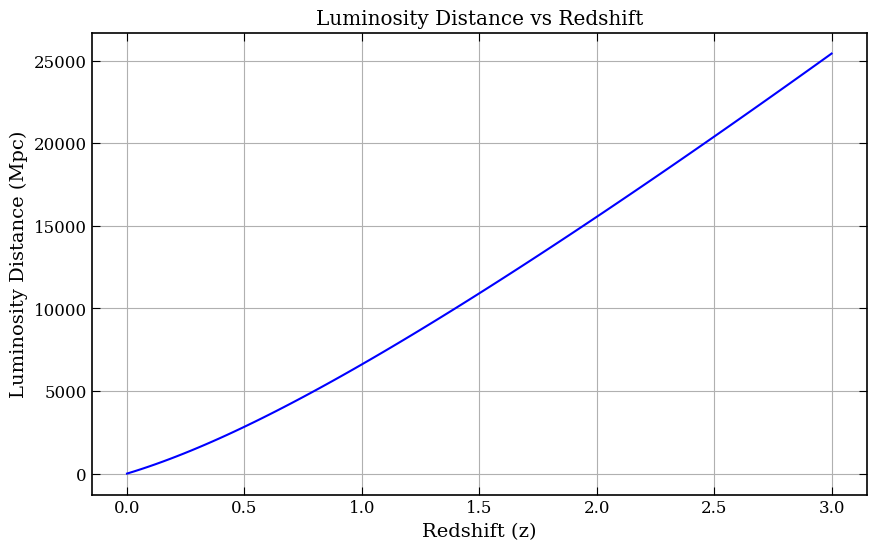

In [6]:
z_values = np.linspace(0.001, 3, 100)  

d_L_values = [luminosity_distance(z, H0, Omega_m) for z in z_values]

plt.figure(figsize=(10, 6))
plt.plot(z_values, d_L_values, label='Luminosity Distance', color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('Luminosity Distance (Mpc)')
plt.title('Luminosity Distance vs Redshift')
plt.grid()
plt.show()

#### Before build the neural network, we need to take care about some suitable settings about the input and the outout information:
* **Log Transform:** We predict $\log_{10}(D_L)$ instead of $D_L$ directly. **Reason:** $D_L$ spans over 3 orders of magnitude.

* **Normalization:** Both inputs and outputs scaled to [0,1] via MinMaxScaler. This ensures equal contribution of all features to the gradient.


In [7]:

log_DL_train = np.log10(DL_train)
log_DL_val = np.log10(DL_val)

scaler_X_DL = MinMaxScaler()
X_train_n = scaler_X_DL.fit_transform(X_train)
X_val_n = scaler_X_DL.transform(X_val)

scaler_Y_DL = MinMaxScaler()
Y_train_DL = scaler_Y_DL.fit_transform(log_DL_train.reshape(-1, 1)).ravel()
Y_val_DL = scaler_Y_DL.transform(log_DL_val.reshape(-1, 1)).ravel()

In [8]:
# define the neural network architecture

model_DL = keras.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
], name='DL_emulator')

model_DL.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')


In [9]:
# Define callbacks on the training process and learning rate when a metric has stopped improving.

cb_DL = [callbacks.EarlyStopping(patience=20, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6)]

In [10]:
history_DL = model_DL.fit(X_train_n, Y_train_DL,
                          validation_data=(X_val_n, Y_val_DL),
                          epochs=200, batch_size=512, verbose=1, callbacks=cb_DL)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1650 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0068 - val_loss: 9.2445e-04 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7068e-04 - val_loss: 3.2880e-04 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7780e-04 - val_loss: 1.8007e-04 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8024e-04 - val_loss: 1.1574e-04 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1985e-04 - val_loss: 8.1482e-05 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.8385e-05 - val_loss: 6.5468e-05 - learning_rate: 0.0010
Epoch 8/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5004e-05 - val_loss: 5.8852e-05 - learning_rate: 0.0010
Epoch 9/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.3773e-05 - val_

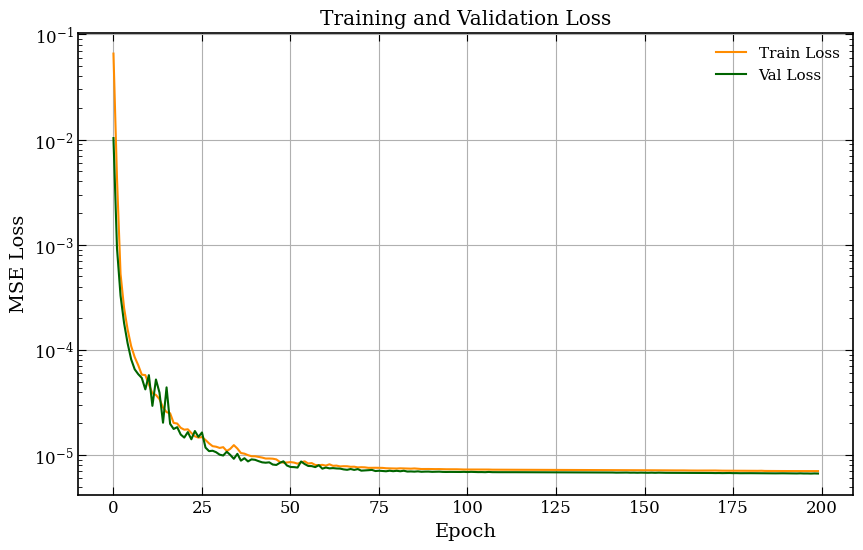

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(history_DL.history['loss'], label='Train Loss',color='darkorange')
plt.plot(history_DL.history['val_loss'], label='Val Loss',color='darkgreen')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [12]:
# Evaluate DL emulator
Y_pred_n = model_DL.predict(X_val_n).ravel()
log_DL_pred = scaler_Y_DL.inverse_transform(Y_pred_n.reshape(-1, 1)).ravel()
DL_pred = 10**log_DL_pred

rel_err_DL = np.abs(DL_pred - DL_val) / DL_val * 100
err_95_DL = np.sort(rel_err_DL)[int(0.95 * len(rel_err_DL))]

print(f"\nDL Emulator Results:")
print(f"  Mean error: {np.mean(rel_err_DL):.4f}%")
print(f"  95th percentile: {err_95_DL:.4f}% (target: <3%)")
print(f"  Status: {'PASS' if err_95_DL < 3 else 'FAIL'}")


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step

DL Emulator Results:
  Mean error: 1.0842%
  95th percentile: 3.0081% (target: <3%)
  Status: FAIL


### Create an emulator of the distance modulus
#### using the formula 
$$

\mu  = 5 \log_{10} \left( \frac{D_L(z)}{10\; pc}\right)
$$
* In this case we use ELU (Exponential Linear Unit) activation function instead of ReLU for the hidden layers due to ELU is smooth everywhere and it has non-zero gradients for negative inputs and a linear function for the output. 
* In this case we use 4 hidden layers, with the first hidden layer with 256, second one of 128, third one of 64 and the last one with 32 activatio units with the goal of finer features. 
* I have use a batchsize of 512 due to larger batches compute more stable gradient estimates reducing the variance.



In [13]:
scaler_X_mu = MinMaxScaler()
X_train_mu = scaler_X_mu.fit_transform(X_train)
X_val_mu = scaler_X_mu.transform(X_val)

scaler_Y_mu = MinMaxScaler()
Y_train_mu = scaler_Y_mu.fit_transform(mu_train.reshape(-1, 1)).ravel()
Y_val_mu = scaler_Y_mu.transform(mu_val.reshape(-1, 1)).ravel()


In [14]:
model_mu = keras.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(256, activation='elu'),
    layers.Dense(128, activation='elu'),
    layers.Dense(64, activation='elu'),
    layers.Dense(32, activation='elu'),
    layers.Dense(1, activation='linear')
], name='mu_emulator')


In [15]:
model_mu.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')


In [16]:
cb_mu = [callbacks.EarlyStopping(patience=30, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6)]

In [17]:
history_mu = model_mu.fit(X_train_mu, Y_train_mu,
                          validation_data=(X_val_mu, Y_val_mu),
                          epochs=500, batch_size=512, verbose=1, callbacks=cb_mu)


Epoch 1/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1042 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 2/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 3/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0026 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 4/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - val_loss: 9.9123e-04 - learning_rate: 0.0010
Epoch 5/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.5179e-04 - val_loss: 7.6729e-04 - learning_rate: 0.0010
Epoch 6/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1953e-04 - val_loss: 6.4747e-04 - learning_rate: 0.0010
Epoch 7/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4954e-04 - val_loss: 5.0111e-04 - learning_rate: 0.0010
Epoch 8/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7007e-04 - val_loss: 3.6855e-04 - learning_rate: 0.0010
Epoch 9/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.8202e-04 - val_loss: 2.9681e-04

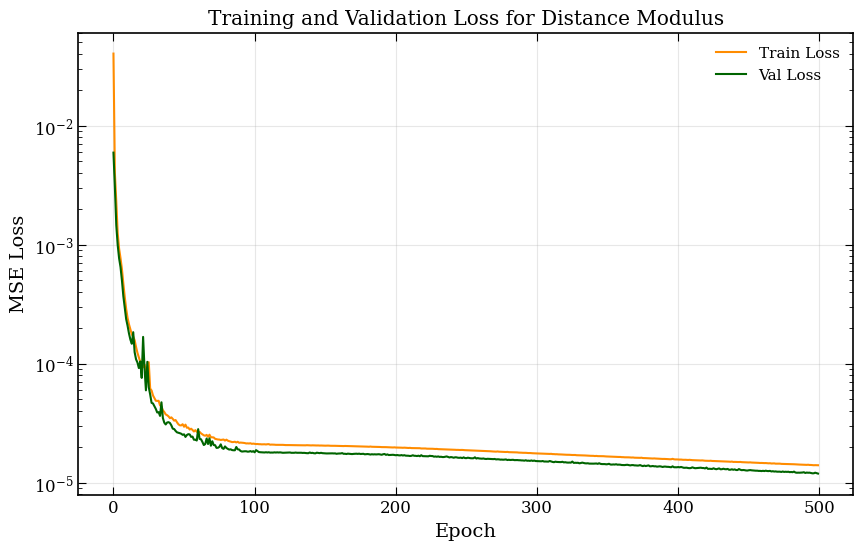

In [25]:

plt.figure(figsize=(10, 6))
plt.semilogy(history_mu.history['loss'], label='Train Loss', color='darkorange')
plt.semilogy(history_mu.history['val_loss'], label='Val Loss', color='darkgreen')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss for Distance Modulus')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Evaluate mu emulator (Point 7)
Y_pred_mu = model_mu.predict(X_val_mu).ravel()
mu_pred = scaler_Y_mu.inverse_transform(Y_pred_mu.reshape(-1, 1)).ravel()

rel_err_mu = np.abs(mu_pred - mu_val) / mu_val * 100
err_95_mu = np.sort(rel_err_mu)[int(0.95 * len(rel_err_mu))]

print(f"\nmu Emulator Results:")
print(f"  Mean relative error: {np.mean(rel_err_mu):.5f}%")
print(f"  Median relative error: {np.median(rel_err_mu):.5f}%")
print(f"  95th percentile: {err_95_mu:.5f}% (target: <1%)")
print(f"  Status: {'PASS' if err_95_mu < 1 else 'FAIL'}")



250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step

mu Emulator Results:
  Mean relative error: 0.04923%
  Median relative error: 0.02550%
  95th percentile: 0.12974% (target: <1%)
  Status: PASS


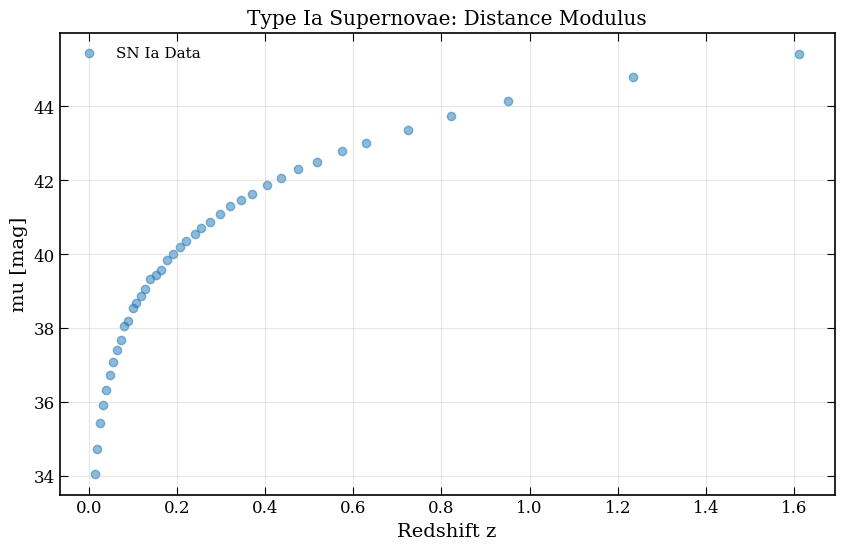

In [20]:
# POINT 8: Read and Plot SN Ia Data

SN_data = np.loadtxt('Data_SNIa_mu.txt')
z_SN = SN_data[:, 0]
mu_SN = SN_data[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(z_SN, mu_SN, marker= 'o', alpha=0.5, label='SN Ia Data')
z_th = np.linspace(0.01, 2.5, 200)
plt.xlabel('Redshift z'); plt.ylabel('mu [mag]')
plt.title('Type Ia Supernovae: Distance Modulus'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [21]:
# POINT 9: Emulator Prediction Function

def mu_emulator_predict(z_arr, H0, Omega_m):
    """Predict mu using the trained NN for given redshifts and cosmology."""
    z_arr = np.atleast_1d(z_arr)
    N = len(z_arr)
    X = np.column_stack([z_arr, np.full(N, H0), np.full(N, Omega_m)])
    X_norm = scaler_X_mu.transform(X)
    Y_norm = model_mu.predict(X_norm, verbose=0).ravel() # predict the normalized mu values using the trained model
    return scaler_Y_mu.inverse_transform(Y_norm.reshape(-1, 1)).ravel()


In [22]:
# =============================================================================
# POINT 10: L1 Distance Function
# =============================================================================

def L1_distance(params, z_data, mu_data):
    """L1 distance between data and emulator predictions."""
    H0, Omega_m = params
    if H0 < 60 or H0 > 85 or Omega_m < 0.1 or Omega_m > 0.5:
        return 1e10
    mu_model = mu_emulator_predict(z_data, H0, Omega_m)
    return np.sum(np.abs(mu_data - mu_model))

def chi2_distance(params, z_data, mu_data):
    """Chi-squared statistic for Gaussian-distributed data."""
    H0, Omega_m = params
    if H0 < 60 or H0 > 85 or Omega_m < 0.1 or Omega_m > 0.5:
        return 1e10
    mu_model = mu_emulator_predict(z_data, H0, Omega_m)
    return np.sum(((mu_data - mu_model))**2)



Best-fit cosmology (chi2): H0 = 65.67, Omega_m = 0.2842
Best-fit cosmology (L1):   H0 = 64.91, Omega_m = 0.3105


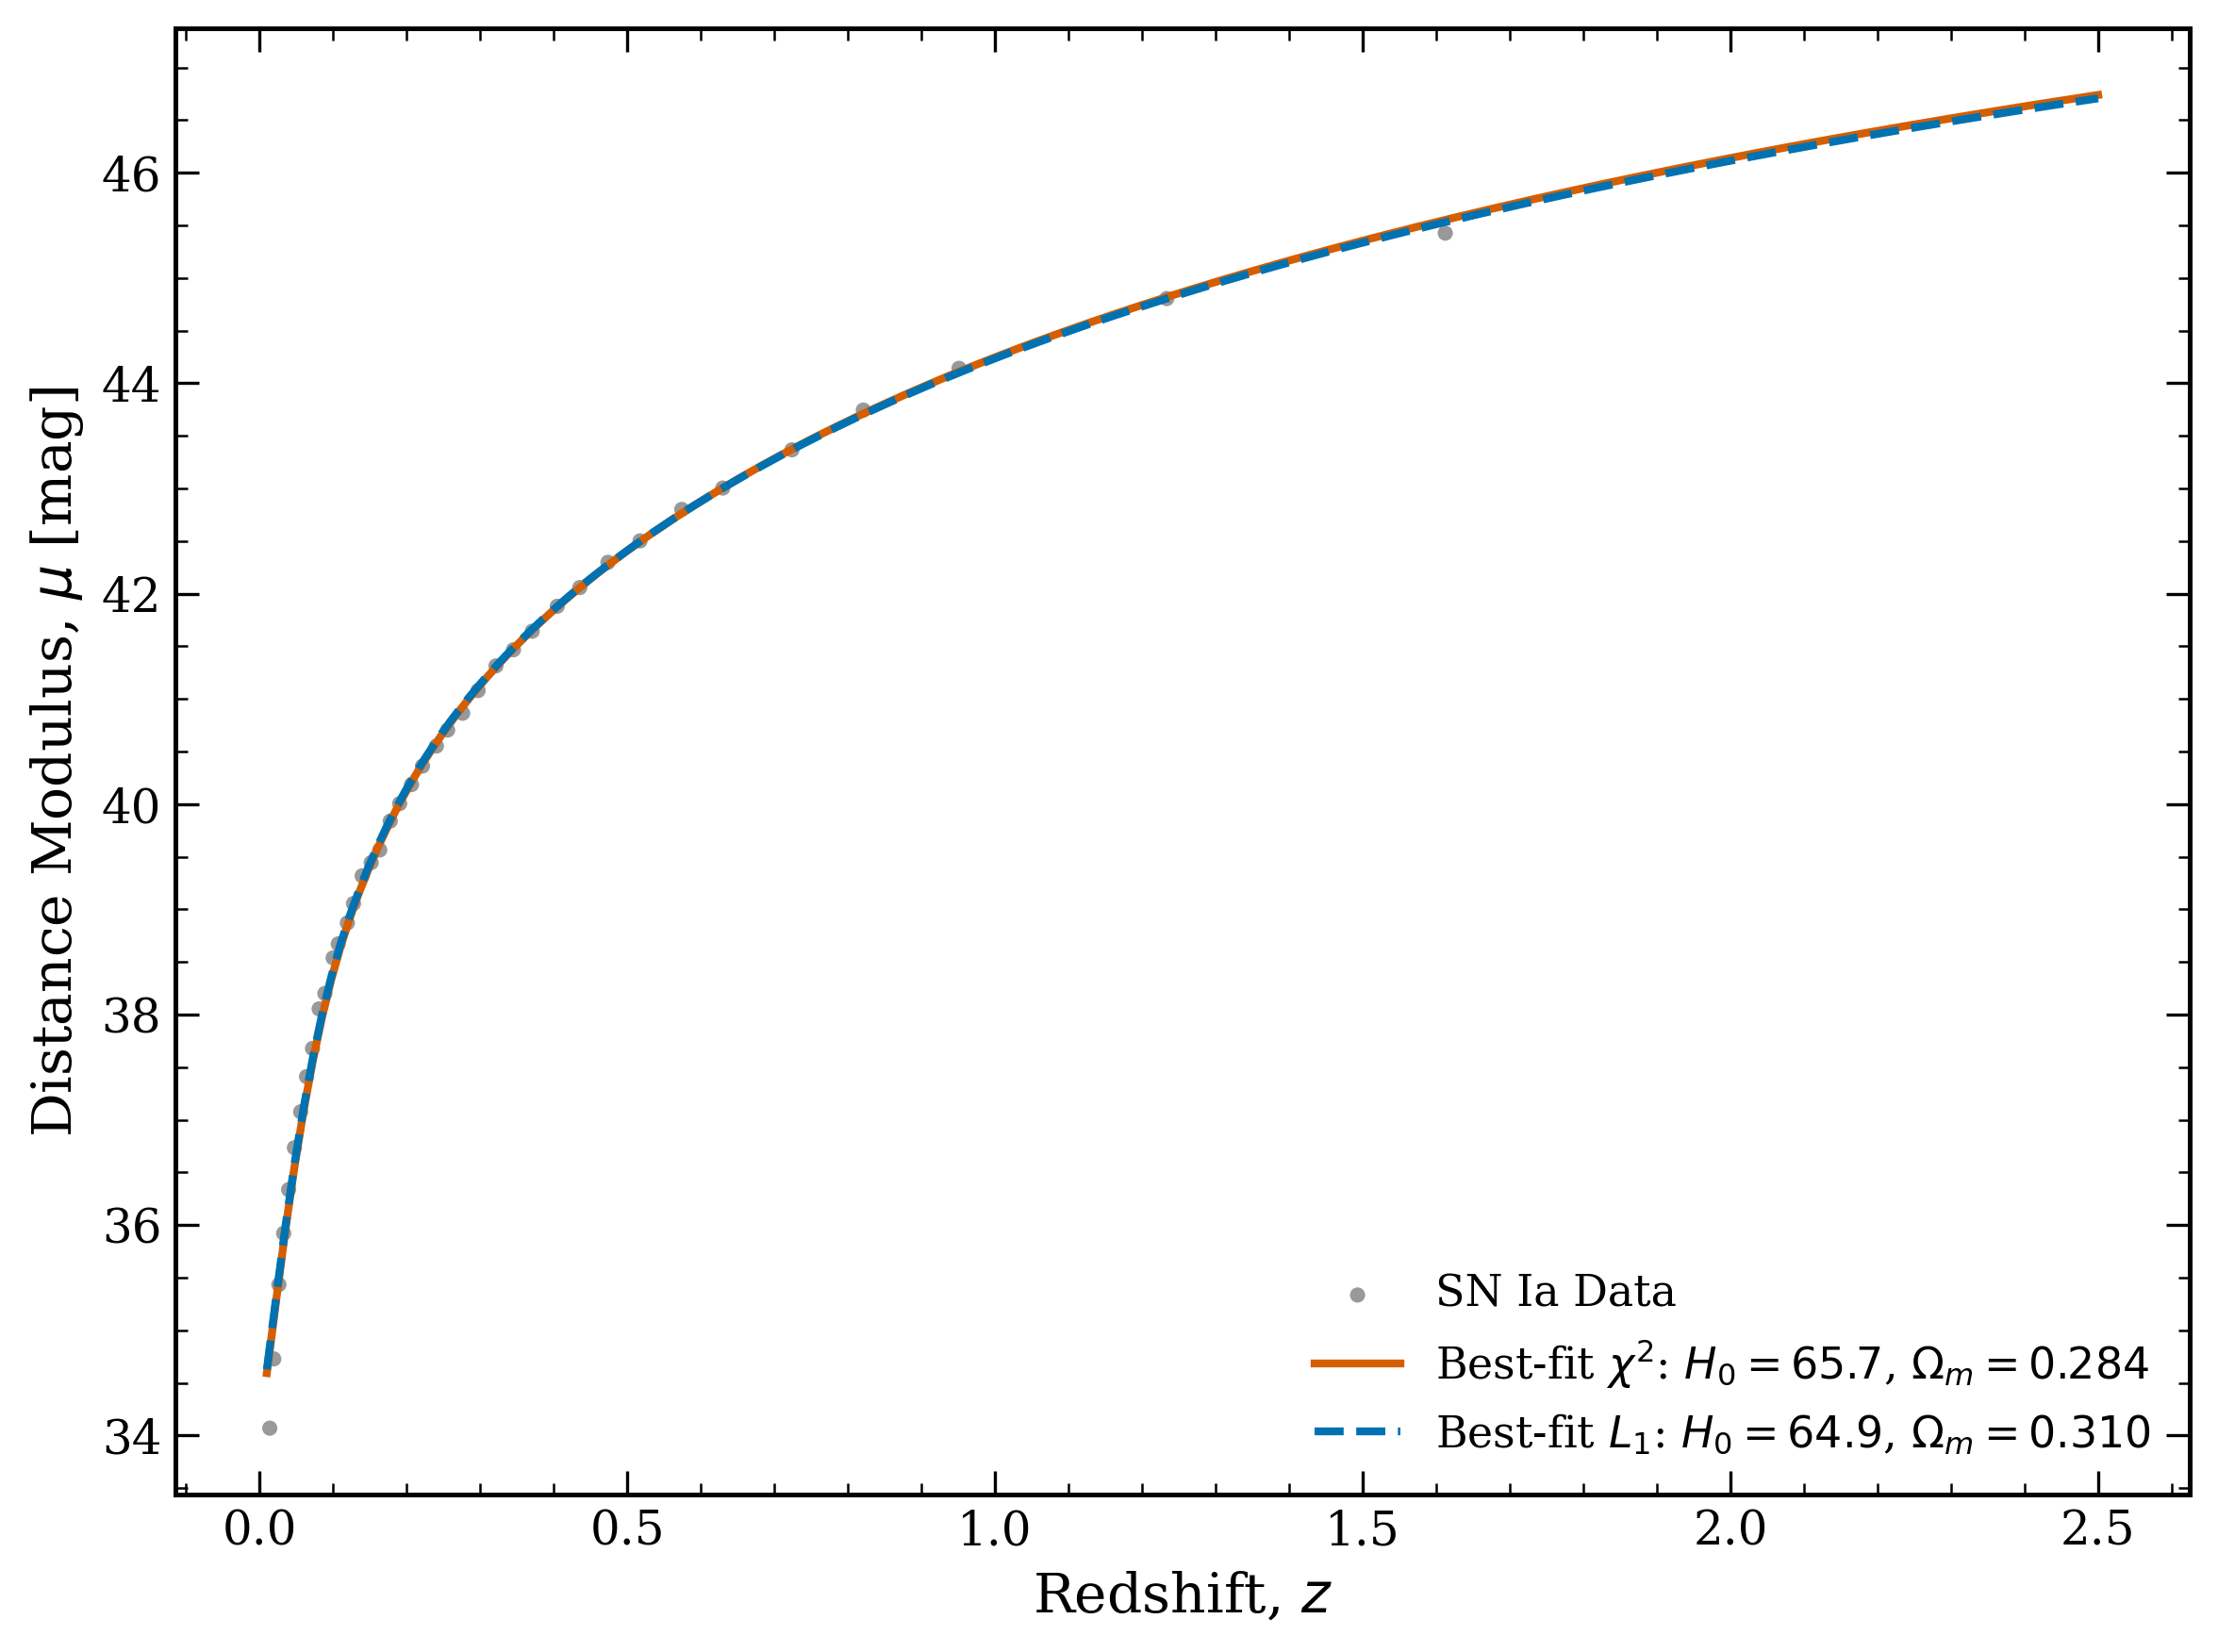

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# --- 2. Optimization ---
p0 = [70.0, 0.3]  # Initial guess [H0, Omega_m]

result_chi2 = optimize.minimize(chi2_distance, p0, args=(z_SN, mu_SN),
                                method='Nelder-Mead')
result_L1 = optimize.minimize(L1_distance, p0, args=(z_SN, mu_SN),
                              method='Nelder-Mead')

H0_fit, Om_fit = result_chi2.x
H0_L1, Om_L1 = result_L1.x

print(f"Best-fit cosmology (chi2): H0 = {H0_fit:.2f}, Omega_m = {Om_fit:.4f}")
print(f"Best-fit cosmology (L1):   H0 = {H0_L1:.2f}, Omega_m = {Om_L1:.4f}")

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(8, 6), dpi=300) # dpi=300 for publication quality

# Data (using black, slightly transparent markers for density visualization)
ax.scatter(z_SN, mu_SN, marker='o', s=15, color='black', alpha=0.4, 
           edgecolors='none', label='SN Ia Data')

# Generate theoretical curves
z_fit = np.linspace(0.01, 2.5, 200)
mu_chi2_pred = mu_emulator_predict(z_fit, H0_fit, Om_fit)
mu_L1_pred = mu_emulator_predict(z_fit, H0_L1, Om_L1)

# Plot chi2 best fit (Colorblind-friendly vermilion)
ax.plot(z_fit, mu_chi2_pred, color='#D55E00', linestyle='-', linewidth=2,
        label=rf'Best-fit $\chi^2$: $H_0={H0_fit:.1f}$, $\Omega_m={Om_fit:.3f}$')

# Plot L1 best fit (Colorblind-friendly blue)
ax.plot(z_fit, mu_L1_pred, color='#0072B2', linestyle='--', linewidth=2,
        label=rf'Best-fit $L_1$: $H_0={H0_L1:.1f}$, $\Omega_m={Om_L1:.3f}$')

# Formatting labels with LaTeX
ax.set_xlabel(r'Redshift, $z$')
ax.set_ylabel(r'Distance Modulus, $\mu$ [mag]')

# Academic touches
ax.minorticks_on()                # Add minor ticks
ax.legend(loc='lower right')      # Add legend

plt.tight_layout()                # Ensure labels don't get cut off
plt.show()